In [1]:
!pip install pyarrow fastparquet

In [2]:
import pandas as pd
import numpy as np

In [3]:
events = pd.read_parquet("C:/Users/treye/Downloads/events.parquet")
stints = pd.read_parquet("C:/Users/treye/Downloads/stints.parquet")
games = pd.read_parquet("C:/Users/treye/Downloads/games.parquet")
players = pd.read_parquet("C:/Users/treye/Downloads/players.parquet")
tracking = pd.read_parquet("C:/Users/treye/Downloads/tracking.parquet")

In [4]:
pd.set_option('display.max_columns', None)

In [6]:
tracking["player_name"].value_counts()

player_name
Grimaldi, Rocco        29734
Bourque, Mavrik        28725
Petrovic, Alexander    28465
Walker, Sammy          27936
Fogarty, Steven        27721
                       ...  
Bednard, Ryan             59
Brodeur, Jeremy           56
Tarasov, Daniil           46
Gibson, Mitchell          34
Nedeljkovic, Alex         10
Name: count, Length: 771, dtype: int64

In [5]:
events["dzone"] = (events["x_adj"] < -25.0).astype(int)
events["nzone"] = ((events["x_adj"] >= -25.0) & (events["x_adj"] <= 25.0)).astype(int)
events["ozone"] = (events["x_adj"] > 25.0).astype(int)
events["game_event_id"] = events["game_id"].astype(str) + "_" + events["sl_event_id"].astype(str)
events["next_event"] = (
    events.groupby("game_id")["event_type"].shift(-1)
)

events["second_next_event"] = (
    events.groupby("game_id")["event_type"].shift(-2)
)

events["last_event"] = (
    events.groupby("game_id")["event_type"].shift(1)
)

events["next_game_event_id"] = (
    events.groupby("game_id")["game_event_id"].shift(-1)
)

events["next_event_player_id"] = (
    events.groupby("game_id")["player_id"].shift(-1)
)

events["second_next_game_event_id"] = (
    events.groupby("game_id")["game_event_id"].shift(-2)
)

events["second_next_event_player_id"] = (
    events.groupby("game_id")["player_id"].shift(-2)
)

events["next_x"] = (
    events.groupby("game_id")["x"].shift(-1)
)

events["next_y"] = (
    events.groupby("game_id")["y"].shift(-1)
)

events["second_next_x"] = (
    events.groupby("game_id")["x"].shift(-2)
)

events["second_next_y"] = (
    events.groupby("game_id")["y"].shift(-2)
)
events["next_x_adj"] = (
    events.groupby("game_id")["x"].shift(-1)
)

events["next_y_adj"] = (
    events.groupby("game_id")["y"].shift(-1)
)

events["second_next_x_adj"] = (
    events.groupby("game_id")["x"].shift(-2)
)

events["second_next_y_adj"] = (
    events.groupby("game_id")["y"].shift(-2)
)

In [6]:
events

,game_id,period,period_time,game_stint,sl_event_id,sequence_id,player_id,player_name,team,team_id,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,game_event_id,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,1.0,0,1,None,None,None,None,None,None,faceoff,None,None,Face-Off,nz,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_0,faceoff,faceoff,NaN,00b0366a-95c6-5250-2dae-e3dd5c4198bc_1,8cdcb61e-d733-bde6-a101-ef3140e48149,00b0366a-95c6-5250-2dae-e3dd5c4198bc_2,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,-0.201431,-0.755550,-0.201431,-0.755550,-0.201431,-0.755550,-0.201431,-0.755550
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,1.0,1,1,8cdcb61e-d733-bde6-a101-ef3140e48149,"L'Esperance, Joel",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,faceoff,failed,"centerfodot, righthandedopponent",NZ FACE OFF-,none,NaN,-0.201431,-0.755550,-0.201431,-0.755550,1,1,0,1,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_1,faceoff,lpr,faceoff,00b0366a-95c6-5250-2dae-e3dd5c4198bc_2,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_3,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,-0.201431,-0.755550,0.807243,1.257381,-0.201431,-0.755550,0.807243,1.257381
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,1.0,2,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,faceoff,successful,"centerfodot, righthandedopponent",NZ REC FACE OFF+ENTRY,recoveredwithentry,NaN,-0.201431,-0.755550,0.201431,0.755550,1,1,0,1,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_2,lpr,pass,faceoff,00b0366a-95c6-5250-2dae-e3dd5c4198bc_3,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_4,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,0.807243,1.257381,0.304306,0.845894,0.807243,1.257381,0.304306,0.845894
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0.070000000,1.0,3,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,lpr,successful,None,F/OFF LPR+ NZ,faceoff,NaN,0.807243,1.257381,-0.807243,-1.257381,1,1,0,1,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_3,pass,reception,faceoff,00b0366a-95c6-5250-2dae-e3dd5c4198bc_4,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_5,0753b094-9e2f-976d-85c8-d22a1d280e8d,0.304306,0.845894,6.339600,20.917810,0.304306,0.845894,6.339600,20.917810
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0.130000000,1.0,4,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,eastside,NZPASS south+,south,NaN,0.304306,0.845894,-0.304306,-0.845894,1,1,0,1,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_4,reception,pass,lpr,00b0366a-95c6-5250-2dae-e3dd5c4198bc_5,0753b094-9e2f-976d-85c8-d22a1d280e8d,00b0366a-95c6-5250-2dae-e3dd5c4198bc_6,0753b094-9e2f-976d-85c8-d22a1d280e8d,6.339600,20.917810,6.339600,23.386793,6.339600,20.917810,6.339600,23.386793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800459,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca,3,1185.800000000,393.0,3595,55,00107e79-8a36-de05-69c7-86087051c558,"Lombardi, Amadeus",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,lpr,successful,None,OFF LPR NZ,none,NaN,-17.800873,24.394117,-17.800873,24.394117,1,1,0,1,0,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3595,dumpin,dumpinagainst,puckprotection,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3596,00107e79-8a36-de05-69c7-86087051c558,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3597,b6a7a39b-5

In [7]:
events.isna().sum()

game_id                              0
period                               0
period_time                          0
game_stint                        1053
sl_event_id                          0
sequence_id                          0
player_id                        64310
player_name                      64310
team                             64310
team_id                          64310
opp_team                         64310
opp_team_id                      64310
event_type                           0
outcome                          64310
flags                           990106
description                          0
detail                               0
sl_xg_all_shots                1746484
x                                64310
y                                64310
x_adj                            64310
y_adj                            64310
has_tracking_data                    0
event_player_tracked                 0
dzone                                0
nzone                    

In [8]:
dzonepasses = events[((events["event_type"] == "pass")  
& ((events["detail"] == "d2d") | (events["detail"] == "d2doffboards") | (events["detail"] == "outlet") | (events["detail"] == "outletoffboards") |
   (events["detail"] == "stretch") | (events["detail"] == "stretchoffboards") | (events["detail"] == "ozentrystretch") | 
   (events["detail"] == "ozentrystretchoffboards")) & (
    ((events["next_event"]=="reception") | (events["next_event"]=="failedpasslocation")) | 
    ((events["next_event"]=="icing")&(events["second_next_event"]=="failedpasslocation"))
   ) | 
         ((events["event_type"] == "icing") & (events["dzone"]==1) & (events["next_event"]=="failedpasslocation") & (events["last_event"]!="pass"))) 
                & (events["event_player_tracked"]==1)].copy()

In [9]:
dzonepasses

,game_id,period,period_time,game_stint,sl_event_id,sequence_id,player_id,player_name,team,team_id,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,game_event_id,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj
17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574
24,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,31.170000000,2.0,24,1,cb8a6b8b-c5a6-4bfe-10b7-15c784b83a7d,"Bjork, Marcus",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westeast,DZONE D2D+,d2d,NaN,67.195480,-31.342346,-67.195480,31.342346,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_24,reception,pass,lpr,00b0366a-95c6-5250-2dae-e3dd5c4198bc_25,0753b094-9e2f-976d-85c8-d22a1d280e8d,00b0366a-95c6-5250-2dae-e3dd5c4198bc_26,0753b094-9e2f-976d-85c8-d22a1d280e8d,59.148422,28.416204,37.019012,32.942677,59.148422,28.416204,37.019012,32.942677
41,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,50.230000000,6.0,41,1,efbd8365-7b4a-13f4-6a00-d77d11d64910,"Christiansen, Jake",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZONE D2D+,d2d,NaN,88.319016,-26.907326,-88.319016,26.907326,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_41,reception,pass,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_42,f7d87866-fb2a-6a94-5317-d30145102fef,00b0366a-95c6-5250-2dae-e3dd5c4198bc_43,f7d87866-fb2a-6a94-5317-d30145102fef,33.498430,-28.416153,35.007248,-25.901443,33.498430,-28.416153,35.007248,-25.901443
43,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,52.830000000,6.0,43,1,f7d87866-fb2a-6a94-5317-d30145102fef,"Meyer, Carson",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,failed,westside,DZONE D2D-,d2d,NaN,35.007248,-25.901443,-35.007248,25.901443,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_43,failedpasslocation,lpr,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_44,f7d87866-fb2a-6a94-5317-d30145102fef,00b0366a-95c6-5250-2dae-e3dd5c4198bc_45,cf9158fc-30e9-680c-b9e5-b65717e1e000,60.657240,-23.889679,20.421951,-16.848503,60.657240,-23.889679,20.421951,-16.848503
65,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,81.930000000,9.0,65,1,65195a5e-8639-a163-d566-03adc8582060,"Tuomisto, Antti",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,pass,successful,eastwest,DZ OUTLET PASS+,outlet,NaN,-47.475110,-30.336456,-47.475110,-30.336456,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_65,reception,carry,lpr,00b0366a-95c6-5250-2dae-e3dd5c4198bc_66,7a213ae8-292c-bc7f-83dd-7b14bdcadde1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_67,7a213ae8-292c-bc7f-83dd-7b14bdcadde1,-4.725105,8.298557,-0.198639,11.407658,-4.725105,8.298557,-0.198639,11.407658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800320,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca,3,1084.700000000,383.0,3456,50,65195a5e-8639-a163-d566-03adc8582060,"Tuomisto, Antti",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,pass,successful,eastside,DZ OUTLET PASS OFFBOARDS+,outletoffboards,NaN,-76.644990,-38.473526,-76.644990,-38.

In [10]:
dzonepasses["second_next_event"].value_counts()

second_next_event
pass                      37458
carry                     22465
lpr                       15269
dumpout                    6591
dumpin                     3498
puckprotection             2139
check                      1609
failedpasslocation         1037
block                       981
controlledbreakout          929
controlledentryagainst      578
whistle                     490
dumpinagainst               469
pressure                    223
penalty                     210
offside                      92
reception                    84
penaltydrawn                 57
icing                        49
receptionprevention          41
shot                         12
assist                        9
Name: count, dtype: int64

In [11]:
tester = dzonepasses[((dzonepasses["next_event"]=="failedpasslocation")|(dzonepasses["next_event"]=="reception")) | 
                        ((dzonepasses["next_event"]=="icing")&(dzonepasses["second_next_event"]=="failedpasslocation"))]

In [12]:
tester["next_event"].value_counts()

next_event
reception             79087
failedpasslocation    14174
icing                  1029
Name: count, dtype: int64

In [13]:
tracking["game_event_id"] = tracking["game_id"].astype(str) + "_" + tracking["sl_event_id"].astype(str)
ts = tracking[tracking["game_event_id"].isin(dzonepasses["game_event_id"])]

In [14]:

#ts = ts[["game_event_id", "player_id", "team_id", "tracking_x", "tracking_y", "tracking_vel_x", "tracking_vel_y"]].copy()
#dzonepasses = dzonepasses.merge(ts, left_on=["next_game_event_id", "next_event_player_id"], 
#                                 right_on=["game_event_id", "player_id"], how="left")
#dzonepasses = dzonepasses.rename(columns={"team_id": "team_id_next", "tracking_x": "tracking_x_next", "tracking_y": "tracking_y_next", 
#                                         "tracking_vel_x": "tracking_vel_x_next", "tracking_vel_y": "tracking_vel_y_next"})
#dzonepasses = dzonepasses.merge(ts, left_on=["second_next_game_event_id", "second_next_event_player_id"], 
#                                right_on=["game_event_id", "player_id"], how="left")
#dzonepasses = dzonepasses.rename(columns={"team_id": "team_id_second", "tracking_x": "tracking_x_second", "tracking_y": "tracking_y_second", 
#                                         "tracking_vel_x": "tracking_vel_x_second", "tracking_vel_y": "tracking_vel_y_second"})

In [15]:
ts

,game_id,sl_event_id,team_id,team_name,player_id,player_name,tracking_x,tracking_y,tracking_vel_x,tracking_vel_y,game_event_id
112,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",64.708007,-21.230316,-8.956783,-18.996254,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17
113,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,663df049-a045-0561-16e3-1db633a0723e,"Aston-Reese, Zachary",62.237535,-1.243438,-5.511866,-12.992256,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17
114,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,None,None,85.482286,-0.275591,-0.393705,-0.393705,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17
115,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,8cdcb61e-d733-bde6-a101-ef3140e48149,"L'Esperance, Joel",61.640422,-13.690945,-12.303273,-21.456908,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17
116,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",41.374673,-3.438320,-9.350488,-18.208844,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17
...,...,...,...,...,...,...,...,...,...,...,...
13529142,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca,3589,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,None,None,-51.797902,12.555775,19.094680,-8.070947,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3589
13529143,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca,3589,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,b90aa353-979c-854a-6f54-5a714d009b15,"Hall, Curtis",-53.293965,-1.171260,17.913566,4.822883,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3589
13529144,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca,3589,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,65195a5e-8639-a163-d566-03adc8582060,"Tuomisto, Antti",-73.690947,13.710630,12.204847,-3.838621,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3589
13529145,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca,3589,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,None,None,-41.916012,21.072835,18.799401,-6.200850,ff8386b6-5f9b-4734-00e6-bc8b4c0a4cca_3589


In [16]:
ts.duplicated(
    ["game_event_id", "player_id"]
).sum()

121320

In [17]:
dzonepasses["intended_target_x"] = dzonepasses.apply(lambda x: x["next_x"] if ((x["next_event"]=="reception")|(x["next_event"]=="failedpasslocation")) else x["second_next_x"],axis=1)
dzonepasses["intended_target_y"] = dzonepasses.apply(lambda x: x["next_y"] if ((x["next_event"]=="reception")|(x["next_event"]=="failedpasslocation")) else x["second_next_y"],axis=1)
dzonepasses["intended_target_x_adj"] = dzonepasses.apply(lambda x: x["next_x_adj"] if ((x["next_event"]=="reception")|(x["next_event"]=="failedpasslocation")) else x["second_next_x_adj"],axis=1)
dzonepasses["intended_target_y_adj"] = dzonepasses.apply(lambda x: x["next_y_adj"] if ((x["next_event"]=="reception")|(x["next_event"]=="failedpasslocation")) else x["second_next_y_adj"],axis=1)
dzonepasses["within_dzone"] = (dzonepasses["intended_target_x_adj"]<-25).astype(int)
dzonepasses["flip"] = dzonepasses["x"] != dzonepasses["x_adj"]

In [18]:
ep = ts.merge(dzonepasses, on="game_event_id", how="inner", suffixes=("_tracking", "_event"))
ep["tracking_x_adj"] = ep["tracking_x"]
ep["tracking_y_adj"] = ep["tracking_y"]
ep.loc[ep["flip"], "tracking_x_adj"] *= -1
ep.loc[ep["flip"], "tracking_y_adj"] *= -1

ep["is_event_player"] = (ep["player_id_tracking"]==ep["player_id_event"])
ep["ep_x_adj"] = ep["tracking_x_adj"].where(ep["is_event_player"])
ep["ep_y_adj"] = ep["tracking_y_adj"].where(ep["is_event_player"])
ep["event_player_tracking_x_adj"] = ep.groupby("game_event_id")["ep_x_adj"].transform("max")
ep["event_player_tracking_y_adj"] = ep.groupby("game_event_id")["ep_y_adj"].transform("max")
ep["ep_vel_x"] = ep["tracking_vel_x"].where(ep["is_event_player"])
ep["ep_vel_y"] = ep["tracking_vel_y"].where(ep["is_event_player"])
ep["event_player_tracking_vel_x"] = ep.groupby("game_event_id")["ep_vel_x"].transform("max")
ep["event_player_tracking_vel_y"] = ep.groupby("game_event_id")["ep_vel_y"].transform("max")
ep["pass_distance"] = np.sqrt(((ep["tracking_x_adj"]-ep["intended_target_x_adj"])**2)+((ep["tracking_y_adj"]-ep["intended_target_y_adj"])**2))
ep["pass_angle"] = np.arctan2(ep["intended_target_y_adj"]-ep["tracking_y_adj"], ep["intended_target_x_adj"]-ep["tracking_x_adj"])
ep

,game_id_tracking,sl_event_id_tracking,team_id_tracking,team_name,player_id_tracking,player_name_tracking,tracking_x,tracking_y,tracking_vel_x,tracking_vel_y,game_event_id,game_id_event,period,period_time,game_stint,sl_event_id_event,sequence_id,player_id_event,player_name_event,team,team_id_event,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj,intended_target_x,intended_target_y,intended_target_x_adj,intended_target_y_adj,within_dzone,flip,tracking_x_adj,tracking_y_adj,is_event_player,ep_x_adj,ep_y_adj,event_player_tracking_x_adj,event_player_tracking_y_adj,ep_vel_x,ep_vel_y,event_player_tracking_vel_x,event_player_tracking_vel_y,pass_distance,pass_angle
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",64.708007,-21.230316,-8.956783,-18.996254,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-64.708007,21.230316,True,-64.708007,21.230316,-64.708007,21.230316,-8.956783,-18.996254,-8.956783,-18.996254,88.490727,-0.547106
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,663df049-a045-0561-16e3-1db633a0723e,"Aston-Reese, Zachary",62.237535,-1.243438,-5.511866,-12.992256,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-62.237535,1.243438,False,NaN,NaN,-64.708007,21.230316,NaN,NaN,-8.956783,-18.996254,77.605484,-0.342285
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,None,None,85.482286,-0.275591,-0.393705,-0.393705,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-85.482286,0.275591,False,NaN,NaN,-64.708007,21.230316,NaN,NaN,-8.956783,-18.996254,99.559009,-0.254651
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,8cdcb61e-d733-bde6-a101-ef3140e48149,"L'Esperance, Joel",61.640422,-13.69

In [ ]:
ep

In [20]:
RINK_HALF_LENGTH = 100
RINK_HALF_WIDTH = 42.5
CORNER_RADIUS = 28

dx_end = RINK_HALF_LENGTH - ep["tracking_x_adj"].abs()
dy_side = RINK_HALF_WIDTH - ep["tracking_y_adj"].abs()
dist_flat = np.minimum(dx_end, dy_side)

in_corner = ((np.abs(ep["tracking_x_adj"])>72)&(np.abs(ep["tracking_y_adj"])>14.5))
corner_centers = np.array([[72, 14.5], [72, -14.5], [-72, 14.5], [-72, -14.5]])
coords = ep[["tracking_x_adj", "tracking_y_adj"]].values
corner_dist = np.min(np.sqrt(
    (coords[:,None,0] - corner_centers[:,0])**2 + 
    (coords[:,None,1] - corner_centers[:,1])**2), axis=1)
dist_corner = np.maximum(CORNER_RADIUS - corner_dist, 0)
dist_to_boards = dist_flat.copy()
dist_to_boards[in_corner] = dist_corner[in_corner]
dist_to_boards = np.maximum(dist_to_boards, 0)
ep["dist_to_boards"] = dist_to_boards

ep["ep_dtb"] = ep["dist_to_boards"].where(ep["is_event_player"])
ep["event_player_dist_to_boards"] = ep.groupby("game_event_id")["ep_dtb"].transform("max")
#####   FIX THIS #####

In [21]:
ep["dist_to_boards"].value_counts()

dist_to_boards
0.000000     3998
2.499999      214
0.000417      196
12.470470     116
12.732937     110
             ... 
9.589255        1
10.077490       1
20.530558       1
1.008374        1
19.412326       1
Name: count, Length: 138828, dtype: int64

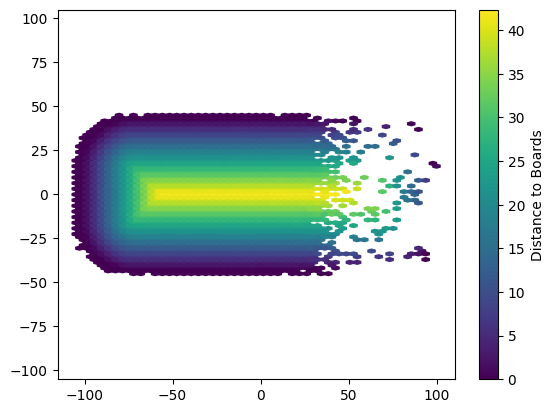

In [22]:
import matplotlib.pyplot as plt

plt.hexbin(
    ep["tracking_x_adj"],
    ep["tracking_y_adj"],
    C=ep["dist_to_boards"],
    gridsize=50
)
plt.colorbar(label="Distance to Boards")
plt.axis("equal")
plt.show()

In [23]:
(ep["tracking_x_adj"]>-25).sum()

83266

In [24]:
(ep["flip"]).sum()

357559

In [25]:
(ep["tracking_x"]==(-1*ep["tracking_x_adj"])).sum()

357561

In [26]:
ep.head(60)

,game_id_tracking,sl_event_id_tracking,team_id_tracking,team_name,player_id_tracking,player_name_tracking,tracking_x,tracking_y,tracking_vel_x,tracking_vel_y,game_event_id,game_id_event,period,period_time,game_stint,sl_event_id_event,sequence_id,player_id_event,player_name_event,team,team_id_event,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj,intended_target_x,intended_target_y,intended_target_x_adj,intended_target_y_adj,within_dzone,flip,tracking_x_adj,tracking_y_adj,is_event_player,ep_x_adj,ep_y_adj,event_player_tracking_x_adj,event_player_tracking_y_adj,ep_vel_x,ep_vel_y,event_player_tracking_vel_x,event_player_tracking_vel_y,pass_distance,pass_angle,t_lane,dist_to_lane,dist_to_boards,ep_dtb,event_player_dist_to_boards
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",64.708007,-21.230316,-8.956783,-18.996254,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-64.708007,21.230316,True,-64.708007,21.230316,-64.708007,21.230316,-8.956783,-18.996254,-8.956783,-18.996254,88.490727,-0.547106,0.000000,0.000000,21.269684,21.269684,21.269684
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,663df049-a045-0561-16e3-1db633a0723e,"Aston-Reese, Zachary",62.237535,-1.243438,-5.511866,-12.992256,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-62.237535,1.243438,False,NaN,NaN,-64.708007,21.230316,NaN,NaN,-8.956783,-18.996254,77.605484,-0.342285,0.141341,15.784286,37.762465,NaN,21.269684
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,Monsters,None,None,85.482286,-0.275591,-0.393705,-0.393705,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-85.482286,0.275591,False,NaN,NaN,-64.708007,21.230316,NaN,NaN,-8.956783,-18.996254,99.559009,-0.254651,

In [27]:
opponents = ep[ep["team_id_tracking"]==ep["opp_team_id"]].copy()
opponents = opponents[opponents["player_id_tracking"].notna()]
opponents["dist_to_event_player"] = np.sqrt((opponents["tracking_x_adj"]-opponents["event_player_tracking_x_adj"])**2 + 
                                            (opponents["tracking_y_adj"]-opponents["event_player_tracking_y_adj"])**2)
opponents["dx"] = opponents["event_player_tracking_x_adj"] - opponents["tracking_x_adj"]
opponents["dy"] = opponents["event_player_tracking_y_adj"] - opponents["tracking_y_adj"]
opponents["ux"] = opponents["dx"] / opponents["dist_to_event_player"]
opponents["uy"] = opponents["dy"] / opponents["dist_to_event_player"]
opponents["closing_vel"] = (opponents["tracking_vel_x"]*opponents["ux"]) + (opponents["tracking_vel_y"]*opponents["uy"])
idx = opponents.groupby("game_event_id")["dist_to_event_player"].idxmin()

closest_forechecker = (
    opponents.loc[idx, [
        "game_event_id",
        "dist_to_event_player",
        "closing_vel"
    ]]
    .rename(columns={
        "dist_to_event_player": "nearest_forechecker_dist",
        "closing_vel": "nearest_forechecker_closing_vel"
    })
)
lane_defenders = ep[ep["team_id_tracking"] == ep["opp_team_id"]]
lane_dist = (
    lane_defenders
    .groupby("game_event_id")["dist_to_lane"]
    .min()
    .reset_index()
    .rename(columns={"dist_to_lane": "nearest_defender_lane_dist"})
)
second_closest_forechecker = opponents.groupby("game_event_id")["dist_to_event_player"].nsmallest(2).groupby(level=0).nth(1).reset_index(name="second_forechecker_dist")
dzonepasses = dzonepasses.merge(closest_forechecker, on="game_event_id", how="left")
dzonepasses = dzonepasses.merge(second_closest_forechecker, on="game_event_id", how="left")
dzonepasses = dzonepasses.merge(ep[["game_event_id", "player_id_tracking", "event_player_dist_to_boards", "pass_distance", "pass_angle"]], left_on=["game_event_id", "player_id"], right_on=["game_event_id", "player_id_tracking"], how="left")
dzonepasses

,game_id,period,period_time,game_stint,sl_event_id,sequence_id,player_id,player_name,team,team_id,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,game_event_id,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj,intended_target_x,intended_target_y,intended_target_x_adj,intended_target_y_adj,within_dzone,flip,nearest_forechecker_dist,nearest_forechecker_closing_vel,level_1,second_forechecker_dist,player_id_tracking,event_player_dist_to_boards,pass_distance,pass_angle
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,8.139545,-15.237982,1.0,20.138980,0753b094-9e2f-976d-85c8-d22a1d280e8d,21.269684,88.490727,-0.547106
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,31.170000000,2.0,24,1,cb8a6b8b-c5a6-4bfe-10b7-15c784b83a7d,"Bjork, Marcus",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westeast,DZONE D2D+,d2d,NaN,67.195480,-31.342346,-67.195480,31.342346,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_24,reception,pass,lpr,00b0366a-95c6-5250-2dae-e3dd5c4198bc_25,0753b094-9e2f-976d-85c8-d22a1d280e8d,00b0366a-95c6-5250-2dae-e3dd5c4198bc_26,0753b094-9e2f-976d-85c8-d22a1d280e8d,59.148422,28.416204,37.019012,32.942677,59.148422,28.416204,37.019012,32.942677,59.148422,28.416204,59.148422,28.416204,0,True,11.678413,-25.486458,NaN,NaN,cb8a6b8b-c5a6-4bfe-10b7-15c784b83a7d,10.144356,129.588894,-0.030404
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,50.230000000,6.0,41,1,efbd8365-7b4a-13f4-6a00-d77d11d64910,"Christiansen, Jake",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZONE D2D+,d2d,NaN,88.319016,-26.907326,-88.319016,26.907326,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_41,reception,pass,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_42,f7d87866-fb2a-6a94-5317-d30145102fef,00b0366a-95c6-5250-2dae-e3dd5c4198bc_43,f7d87866-fb2a-6a94-5317-d30145102fef,33.498430,-28.416153,35.007248,-25.901443,33.498430,-28.416153,35.007248,-25.901443,33.498430,-28.416153,33.498430,-28.416153,0,True,10.193914,-16.877162,11.0,35.517964,efbd8365-7b4a-13f4-6a00-d77d11d64910,5.069661,136.231636,-0.427917
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,52.830000000,6.0,43,1,f7d87866-fb2a-6a94-5317-d30145102fef,"Meyer, Carson",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,failed,westside,DZONE D2D-,d2d,NaN,35.007248,-25.901443,-35.007248,25.901443,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_43,failedpasslocation,lpr,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_44,f7d87866-fb2a-6a94-5317-d30145102fef,00b0366a-95c6-5250-2dae-e3dd5c4198bc_45,cf9158fc-30e9-680c-b9e5-b65717e1e000,60.657240,-23.889679,20.421951,-16.848503,60.657240,-23.889679,20.421951,-16.848503,60.657240,-23.889679,60.657240,-23.889679,0,True,7.911741,3.914076,19.0,12.229090,f7d87866-fb2a-6a94-5317-d30145102fef,20.633201,105.253911,-0.449733
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,81.930000000,9.0,65,1,65195a5e-8639-a163-d566-03adc8582060,"Tuomisto, Antti",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,pass,successful,eastwest,DZ OUTLET PASS+,out

In [28]:
opponents

,game_id_tracking,sl_event_id_tracking,team_id_tracking,team_name,player_id_tracking,player_name_tracking,tracking_x,tracking_y,tracking_vel_x,tracking_vel_y,game_event_id,game_id_event,period,period_time,game_stint,sl_event_id_event,sequence_id,player_id_event,player_name_event,team,team_id_event,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj,intended_target_x,intended_target_y,intended_target_x_adj,intended_target_y_adj,within_dzone,flip,tracking_x_adj,tracking_y_adj,is_event_player,ep_x_adj,ep_y_adj,event_player_tracking_x_adj,event_player_tracking_y_adj,ep_vel_x,ep_vel_y,event_player_tracking_vel_x,event_player_tracking_vel_y,pass_distance,pass_angle,t_lane,dist_to_lane,dist_to_boards,ep_dtb,event_player_dist_to_boards,dist_to_event_player,dx,dy,ux,uy,closing_vel
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,663df049-a045-0561-16e3-1db633a0723e,"Aston-Reese, Zachary",62.237535,-1.243438,-5.511866,-12.992256,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-62.237535,1.243438,False,NaN,NaN,-64.708007,21.230316,NaN,NaN,-8.956783,-18.996254,77.605484,-0.342285,0.141341,15.784286,37.762465,NaN,21.269684,20.138980,-2.470473,19.986877,-0.122671,0.992447,-12.217983
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,17,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,8cdcb61e-d733-bde6-a101-ef3140e48149,"L'Esperance, Joel",61.640422,-13.690945,-12.303273,-21.456908,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,-61.640422,13.690945,False,NaN,NaN,-64.708007,21.230316,NaN,NaN,-8.956783,-18.996254,82.091777,-0.488076,0.073928,4.843066,28.809055,NaN,21.269684,8.139545,-3.067585,7.539370,-0.376874,0.926264,-15.237982
8,00b0366a-95c6-5250-2dae-e3dd5c4198bc,24,6cac12e2-0546-2c1a-689f-ab26d8a6355a,Griffins,663df049-a045-0561-16e3-1db633a0723e,"Aston-Reese, Zachary",58.730317,-31.545277,25.787660,3.444916,00b0366a-95c6-5250-2dae-e3dd5c4198bc_24,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,31.170000000,2.0,24,1,cb8a6b8b-c5a6-4bfe-10b7-15c784b83a7d,"Bjork, Marcus",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westeast,DZONE D2D+,d2d,NaN,67.195480,-31.342346,-67.195480,31.342346,1,1,1,0,0,reception,pass,lpr,00b0366a-95c6-5250-2dae-e3dd5c4198bc_25,0753b094-9e2f-976d-85c8-d22a1d280e8d,00b0366a-95c6-5250-2dae-e3dd5c4198bc_26,0753b094-9e2f-976d-85c8-d22a1d280e8d,59.148422,28.416204,37.019012,32.942677,59.148422,28.416204,37.019012,32.942

In [29]:
dzonepasses = dzonepasses[dzonepasses["nearest_forechecker_dist"].notna()]
dzonepasses = dzonepasses[dzonepasses["second_forechecker_dist"].notna()]
dzonepasses

,game_id,period,period_time,game_stint,sl_event_id,sequence_id,player_id,player_name,team,team_id,opp_team,opp_team_id,event_type,outcome,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked,dzone,nzone,ozone,game_event_id,next_event,second_next_event,last_event,next_game_event_id,next_event_player_id,second_next_game_event_id,second_next_event_player_id,next_x,next_y,second_next_x,second_next_y,next_x_adj,next_y_adj,second_next_x_adj,second_next_y_adj,intended_target_x,intended_target_y,intended_target_x_adj,intended_target_y_adj,within_dzone,flip,nearest_forechecker_dist,nearest_forechecker_closing_vel,level_1,second_forechecker_dist,player_id_tracking,event_player_dist_to_boards,pass_distance,pass_angle
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,23.600000000,1.0,17,1,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZ OUTLET PASS+,outlet,NaN,61.160187,-24.804108,-61.160187,24.804108,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_17,reception,puckprotection,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_18,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,00b0366a-95c6-5250-2dae-e3dd5c4198bc_19,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,14.889603,-29.330574,10.866066,-24.804108,10.866066,-24.804108,0,True,8.139545,-15.237982,1.0,20.138980,0753b094-9e2f-976d-85c8-d22a1d280e8d,21.269684,88.490727,-0.547106
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,50.230000000,6.0,41,1,efbd8365-7b4a-13f4-6a00-d77d11d64910,"Christiansen, Jake",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,westside,DZONE D2D+,d2d,NaN,88.319016,-26.907326,-88.319016,26.907326,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_41,reception,pass,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_42,f7d87866-fb2a-6a94-5317-d30145102fef,00b0366a-95c6-5250-2dae-e3dd5c4198bc_43,f7d87866-fb2a-6a94-5317-d30145102fef,33.498430,-28.416153,35.007248,-25.901443,33.498430,-28.416153,35.007248,-25.901443,33.498430,-28.416153,33.498430,-28.416153,0,True,10.193914,-16.877162,11.0,35.517964,efbd8365-7b4a-13f4-6a00-d77d11d64910,5.069661,136.231636,-0.427917
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,52.830000000,6.0,43,1,f7d87866-fb2a-6a94-5317-d30145102fef,"Meyer, Carson",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,failed,westside,DZONE D2D-,d2d,NaN,35.007248,-25.901443,-35.007248,25.901443,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_43,failedpasslocation,lpr,reception,00b0366a-95c6-5250-2dae-e3dd5c4198bc_44,f7d87866-fb2a-6a94-5317-d30145102fef,00b0366a-95c6-5250-2dae-e3dd5c4198bc_45,cf9158fc-30e9-680c-b9e5-b65717e1e000,60.657240,-23.889679,20.421951,-16.848503,60.657240,-23.889679,20.421951,-16.848503,60.657240,-23.889679,60.657240,-23.889679,0,True,7.911741,3.914076,19.0,12.229090,f7d87866-fb2a-6a94-5317-d30145102fef,20.633201,105.253911,-0.449733
5,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,109.470000000,13.0,88,2,efbd8365-7b4a-13f4-6a00-d77d11d64910,"Christiansen, Jake",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,pass,successful,eastwest,DZONE D2D+,d2d,NaN,32.492540,32.485460,-32.492540,-32.485460,1,1,1,0,0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_88,reception,pass,lpr,00b0366a-95c6-5250-2dae-e3dd5c4198bc_89,27be5d93-9bc0-8a87-41dd-e96fea901efc,00b0366a-95c6-5250-2dae-e3dd5c4198bc_90,27be5d93-9bc0-8a87-41dd-e96fea901efc,43.557250,-13.190735,39.030777,-20.231910,43.557250,-13.190735,39.030777,-20.231910,43.557250,-13.190735,43.557250,-13.190735,0,True,13.475720,-13.305509,32.0,48.743565,efbd8365-7b4a-13f4-6a00-d77d11d64910,10.889107,82.634471,0.224800
7,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,203.930000000,25.0,164,2,00107e79-8a36-de05-69c7-86087051c558,"Lombardi, Amadeus",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,pass,successful,weste

In [30]:
dzonepasses["outcome"] = dzonepasses["outcome"].map({"failed":0, "successful":1})

In [34]:
model_features = ["x_adj", "y_adj", "intended_target_x_adj", "intended_target_y_adj", "within_dzone", "nearest_forechecker_dist", 
                  "nearest_forechecker_closing_vel", "second_forechecker_dist", "event_player_dist_to_boards", "pass_distance", "pass_angle"]
target = "outcome"

In [35]:
dzonepasses=dzonepasses.dropna(subset=["nearest_forechecker_closing_vel"])

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X = dzonepasses[model_features]
y = dzonepasses[target]

pipe = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('logreg', LogisticRegression())])

In [37]:
from sklearn.metrics import roc_auc_score
probs = pipe.predict_proba(X_test)[:,1]
roc_auc_score(y_test, probs)

0.597641653579914

In [38]:
from sklearn.metrics import brier_score_loss
brier_score_loss(y_test, probs)

0.16506768839163968

In [ ]:
dzonepasses["nearest_defender_lane_dist"].hist(bins=50)

In [ ]:
import matplotlib.pyplot as plt

row = ep.sample(1).iloc[0]

plt.scatter(ep["tracking_x_adj"], ep["tracking_y_adj"], alpha=0.2)

plt.plot(
    [row.Px, row.Tx],
    [row.Py, row.Ty],
    color="red"
)

plt.scatter(row.Px, row.Py, c="blue", s=100)
plt.scatter(row.Tx, row.Ty, c="green", s=100)

plt.show()